In [ ]:
import os
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
import json

# Replace with your username and key
kaggle_json = {
    "username": "labidimahdi",
    "key": "KGAT_cd508928a093f9d98f6e6c791a532e15"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download shreyag1103/brain-mri-scans-for-brain-tumor-classification

Dataset URL: https://www.kaggle.com/datasets/shreyag1103/brain-mri-scans-for-brain-tumor-classification
License(s): unknown
  0% 0.00/24.4M [00:00<?, ?B/s]
100% 24.4M/24.4M [00:00<00:00, 1.74GB/s]


In [ ]:
!unzip /content/brain-mri-scans-for-brain-tumor-classification.zip

Archive:  /content/brain-mri-scans-for-brain-tumor-classification.zip
  inflating: data/glioma/Te-glTr_0000.jpg  
  inflating: data/glioma/Te-glTr_0001.jpg  
  inflating: data/glioma/Te-glTr_0002.jpg  
  inflating: data/glioma/Te-glTr_0003.jpg  
  inflating: data/glioma/Te-glTr_0004.jpg  
  inflating: data/glioma/Te-glTr_0005.jpg  
  inflating: data/glioma/Te-glTr_0006.jpg  
  inflating: data/glioma/Te-glTr_0007.jpg  
  inflating: data/glioma/Te-glTr_0008.jpg  
  inflating: data/glioma/Te-glTr_0009.jpg  
  inflating: data/glioma/Te-gl_0010.jpg  
  inflating: data/glioma/Te-gl_0011.jpg  
  inflating: data/glioma/Te-gl_0012.jpg  
  inflating: data/glioma/Te-gl_0013.jpg  
  inflating: data/glioma/Te-gl_0014.jpg  
  inflating: data/glioma/Te-gl_0015.jpg  
  inflating: data/glioma/Te-gl_0016.jpg  
  inflating: data/glioma/Te-gl_0017.jpg  
  inflating: data/glioma/Te-gl_0018.jpg  
  inflating: data/glioma/Te-gl_0019.jpg  
  inflating: data/glioma/Te-gl_0020.jpg  
  inflating: data/glioma/Te-

In [ ]:
ORIGINAL_DATA_DIR = './data'
SPLIT_DATA_DIR = './data_split'

TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

In [ ]:
def create_dataset_splits(source_dir, train_dir, val_dir, test_dir, split_ratio=(0.7, 0.15, 0.15)):
    if not os.path.exists(source_dir):
        print(f"Error: Could not find the source folder: {source_dir}")
        return
    classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    print(f"Discovered {len(classes)} classes of tumors.\nSplitting dataset into {split_ratio} (Train, Val, Test)...\n")
    for class_name in classes:
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        class_folder_path = os.path.join(source_dir, class_name)
        images = os.listdir(class_folder_path)
        random.shuffle(images)

        total_images = len(images)
        train_cut = int(total_images * split_ratio[0])
        val_cut = int(total_images * split_ratio[1])

        train_images = images[:train_cut]
        val_images = images[train_cut : train_cut + val_cut]
        test_images = images[train_cut + val_cut :]

        for img in train_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(train_dir, class_name, img))
        for img in val_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(val_dir, class_name, img)) # Corrected destination
        for img in test_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(test_dir, class_name, img)) # Corrected destination

    print("Success! Images have been split into the robust 'data_split/' directory.")

create_dataset_splits(ORIGINAL_DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

Discovered 4 classes of tumors.
Splitting dataset into (0.7, 0.15, 0.15) (Train, Val, Test)...

Success! Images have been split into the robust 'data_split/' directory.


In [ ]:
def count_images(split_data_dir):
    for main_split in ['train', 'val', 'test']:
        split_path = os.path.join(split_data_dir, main_split)
        if not os.path.exists(split_path):
            os.makedirs(split_path)
            continue
        print(f"\n--- Output for {main_split.upper()} set ---")
        for disease_folder in os.listdir(split_path):
            disease_path = os.path.join(split_path, disease_folder)
            if os.path.isdir(disease_path):
                image_count = len(os.listdir(disease_path))
                print(f"  > {disease_folder}: {image_count} images")
count_images(SPLIT_DATA_DIR)


--- Output for TRAIN set ---
  > pituitary: 210 images
  > glioma: 210 images
  > notumor: 283 images
  > meningioma: 306 images

--- Output for VAL set ---
  > pituitary: 45 images
  > glioma: 45 images
  > notumor: 60 images
  > meningioma: 45 images

--- Output for TEST set ---
  > pituitary: 45 images
  > glioma: 45 images
  > notumor: 62 images
  > meningioma: 47 images


In [ ]:
IMG_SIZE = (224, 224)
# We **do NOT** augment the Validation or Test Sets. We want to test the model on normal, un-altered images.
# BATCH SIZE: How many images the AI processes at once before updating its "memory".
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range = 15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
# LOADING THE IMAGES FROM FOLDERS INTO MEMORY

# Connect the Train Generator to the 'train' folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

Found 1009 images belonging to 4 classes.
Found 195 images belonging to 4 classes.
Found 199 images belonging to 4 classes.


In [ ]:
base_model = DenseNet121(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

predictions = Dense(NUM_CLASSES, activation = 'softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
EPOCHS = 30
MODEL_SAVE_PATH = './saved_model/brain_tumor_densenet121.keras'

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"\n✅ Training concluded! The best version was safely deposited at {MODEL_SAVE_PATH}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 280s 4s/step - accuracy: 0.5576 - loss: 1.2458 - val_accuracy: 0.7846 - val_loss: 0.5717 - learning_rate: 1.0000e-04
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 586ms/step - accuracy: 0.9064 - loss: 0.2791 - val_accuracy: 0.8821 - val_loss: 0.3059 - learning_rate: 1.0000e-04
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 542ms/step - accuracy: 0.9317 - loss: 0.1793 - val_accuracy: 0.9487 - val_loss: 0.1980 - learning_rate: 1.0000e-04
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 563ms/step - accuracy: 0.9634 - loss: 0.1062 - val_accuracy: 0.9487 - val_loss: 0.1973 - learning_rate: 1.0000e-04
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 545ms/step - accuracy: 0.9815 - loss: 0.0640 - val_accuracy: 0.9436 - val_loss: 0.1624 - learning_rate: 1.0000e-04
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 486ms/step - accuracy: 0.9863 - loss: 0.0480 - val_accuracy: 0.9538 - val_loss: 0.1764 - learning_rate: 1.0000e-04
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 567ms/step - accur

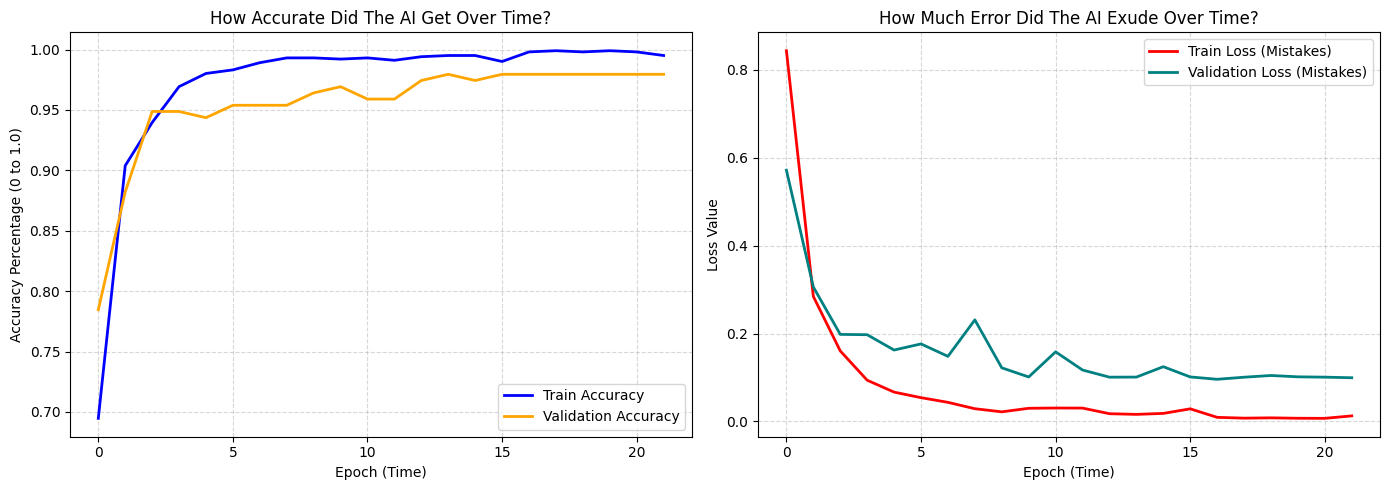

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2, color='blue')
plt.plot(val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.title('How Accurate Did The AI Get Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Accuracy Percentage (0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Mistakes)', linewidth=2, color='red')
plt.plot(val_loss, label='Validation Loss (Mistakes)', linewidth=2, color='teal')
plt.title('How Much Error Did The AI Exude Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss/Error: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9732 - loss: 0.0902
🎯 Final Test Accuracy: 97.49%
📉 Final Test Loss/Error: 0.1017


7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
----------- PREDICTION TEXT REPORT -----------
              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99        45
  meningioma       0.92      1.00      0.96        47
     notumor       1.00      0.94      0.97        62
   pituitary       0.98      1.00      0.99        45

    accuracy                           0.97       199
   macro avg       0.97      0.98      0.98       199
weighted avg       0.98      0.97      0.97       199



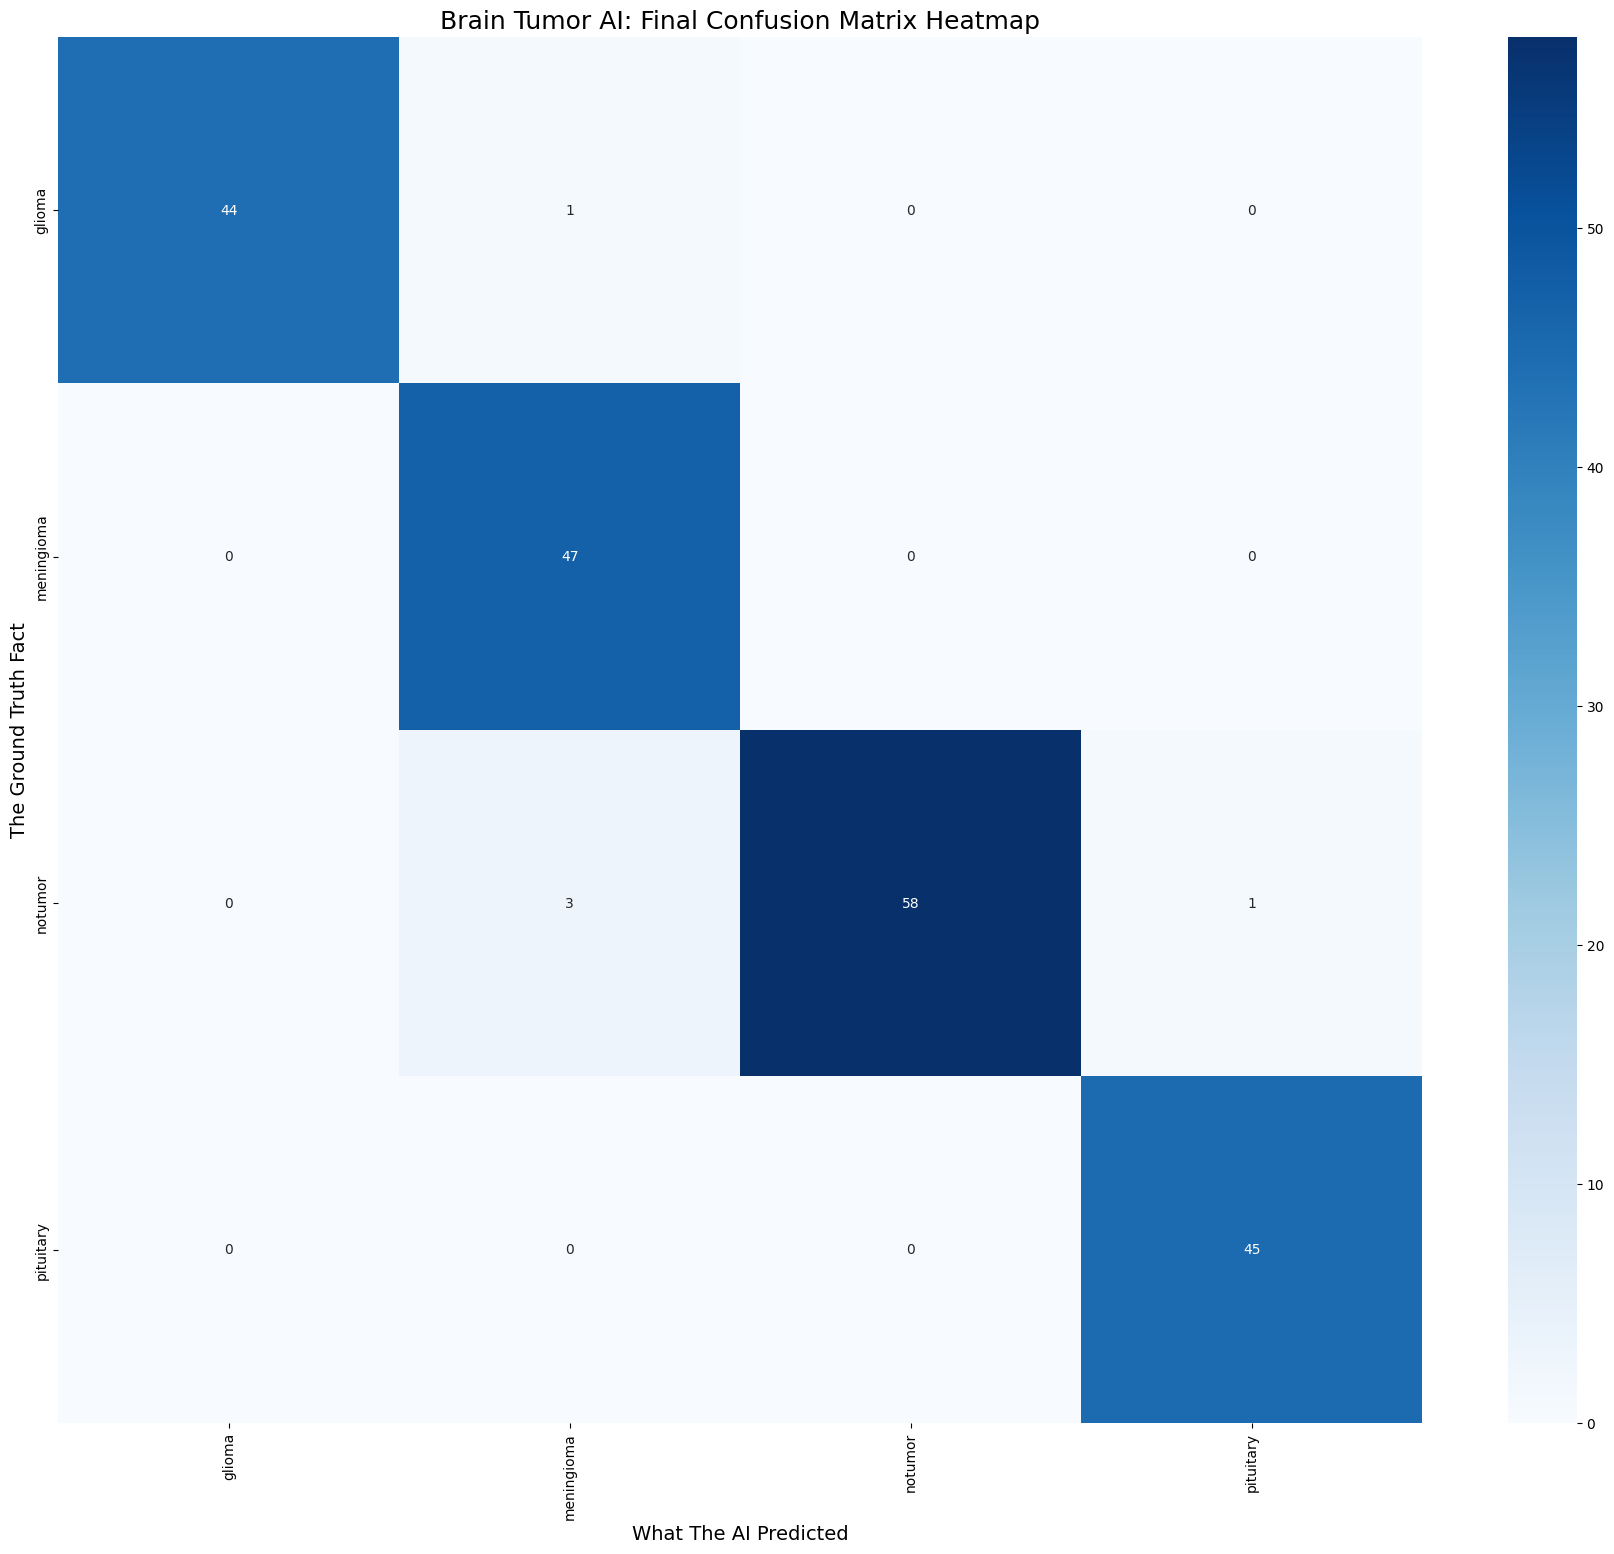

In [ ]:
test_generator.reset()

predictions_prob = model.predict(test_generator)

predicted_classes = np.argmax(predictions_prob, axis=1)

true_classes = test_generator.classes

# --- PRINT TEXTUAL REPORT ---
print("----------- PREDICTION TEXT REPORT -----------")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# --- DRAW CONFUSION MATRIX GRAPH ---
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(22, 18))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Brain Tumor AI: Final Confusion Matrix Heatmap', fontsize=18)
plt.xlabel('What The AI Predicted', fontsize=14)
plt.ylabel('The Ground Truth Fact', fontsize=14)
plt.xticks(rotation=90)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


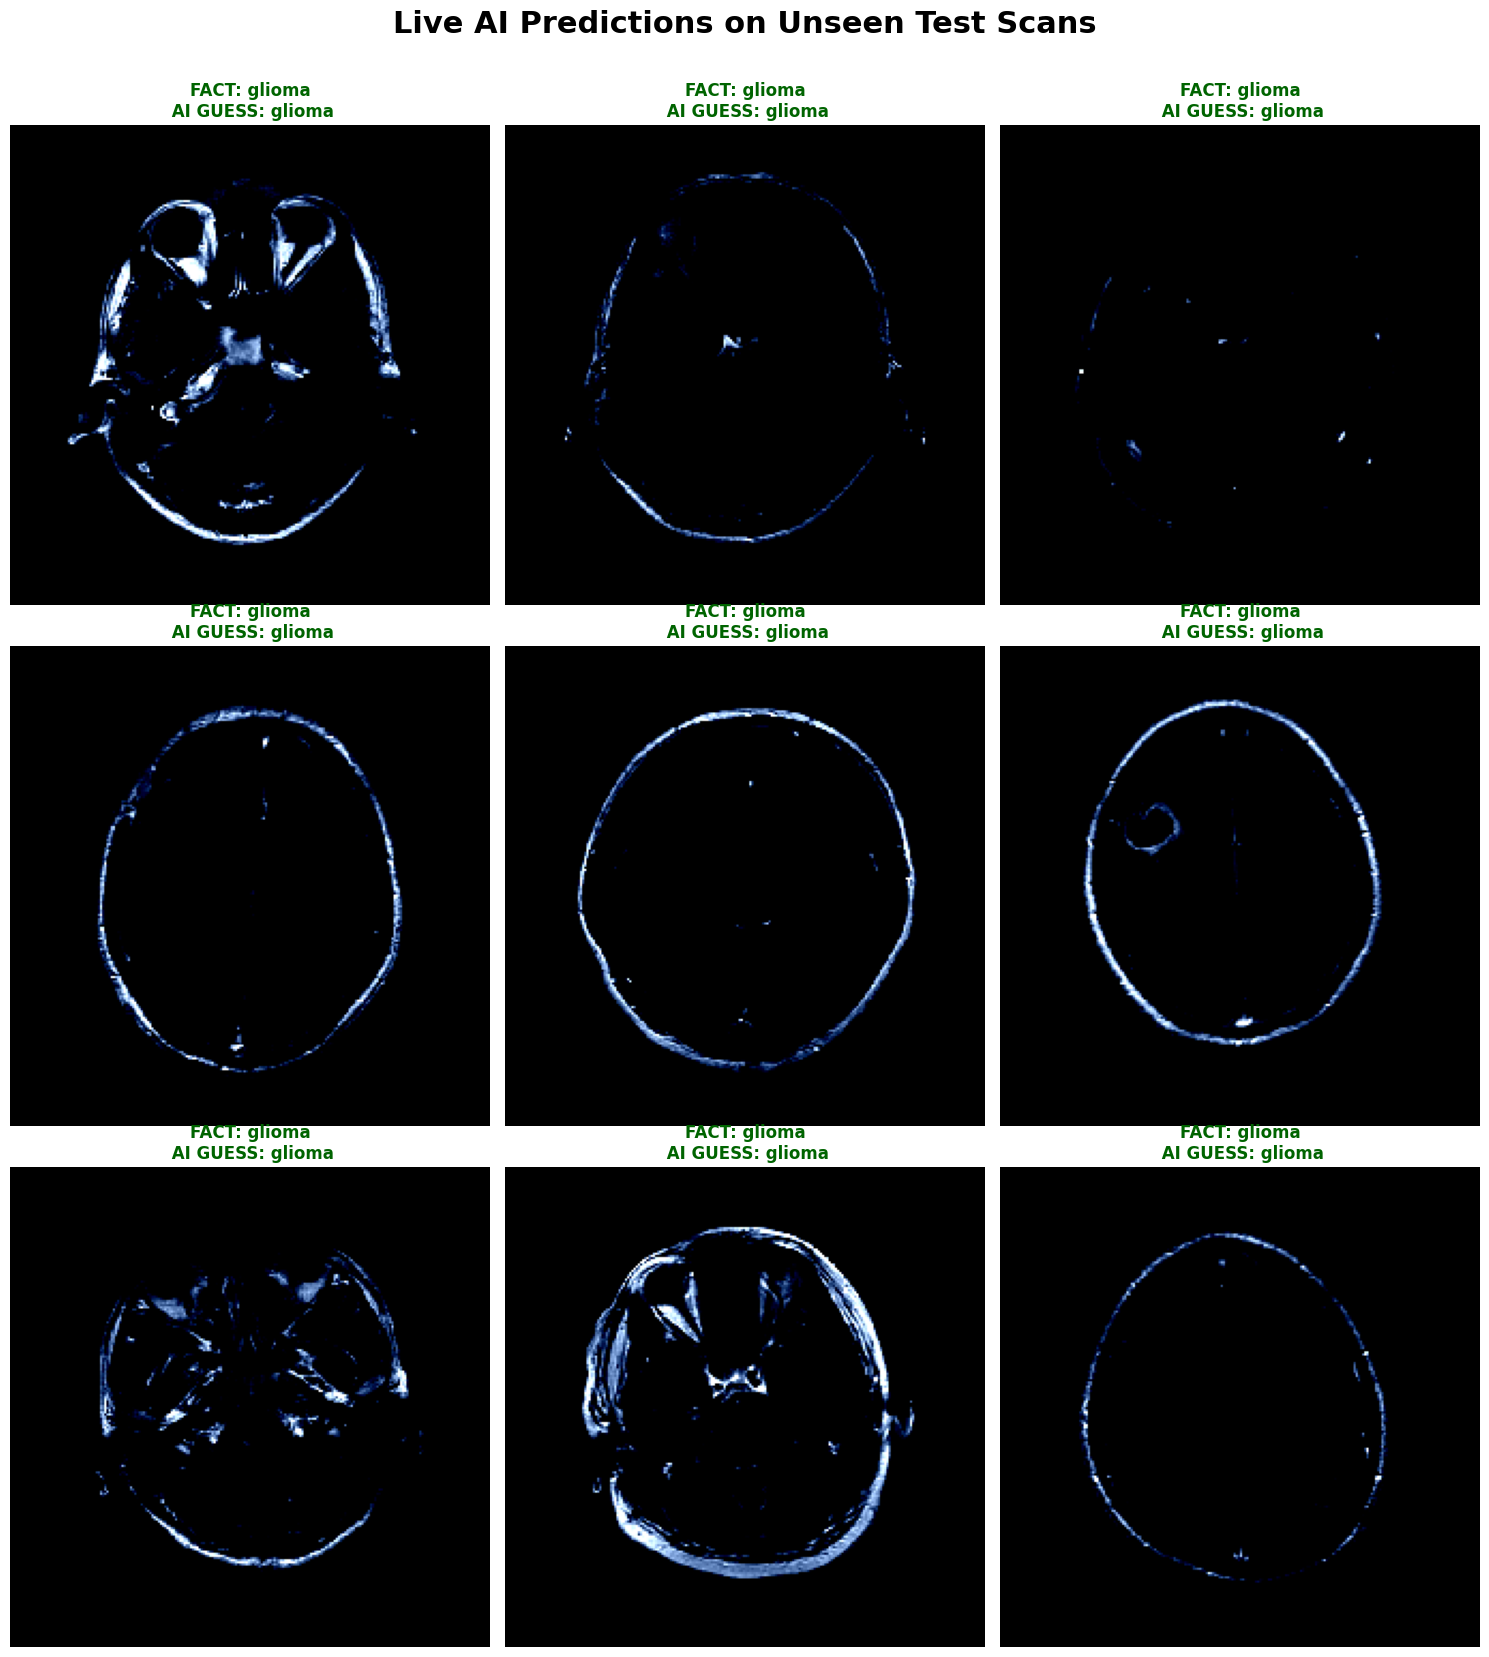

In [ ]:
test_generator.reset()
images, onehot_labels = next(test_generator)

preds = model.predict(images)

pred_ids = np.argmax(preds, axis=1)
true_ids = np.argmax(onehot_labels, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(15, 17))
axes = axes.ravel()

for i in range(9):
    if i < len(images):
        axes[i].imshow(images[i])

        true_name = class_names[true_ids[i]]
        pred_name = class_names[pred_ids[i]]

        text_color = "darkgreen" if true_ids[i] == pred_ids[i] else "darkred"

        axes[i].set_title(f"FACT: {true_name}\n AI GUESS: {pred_name}", color=text_color, fontweight="bold", fontsize=12)
        axes[i].axis('off') # Hide graph axes borders

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('Live AI Predictions on Unseen Test Scans', fontsize=22, fontweight='bold')
plt.show()